In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
import subprocess
Dir_working = r'Z:\study\phd\project\Semantics\Dissemination\table_figure'
Dir_github = r'Z:\study\phd\project\Semantics\FactorAnalysis\github'
repo = 'FactorAnalysis_fMRI'
# path_wb = r'D:\Software\fmri\workbench\bin_windows64'
# path_wb_atlas = r'D:\Software\fmri\workbench\atlas'
path_wb = r'Z:\Software\workbench\bin_windows64'
path_wb_atlas = r'Z:\Software\workbench\atlas'

In [19]:

import re

def make_output_txt(df_output,path_txtOutput):
        
    with open(path_txtOutput, 'w') as f:
        for i,row in df_output.iterrows():
            line = row['label']
            f.write(line + '\n')  # Add newline character explicitly

            line = f"{row['idx']} {row['rgb']} {row['alpha']}"
            f.write(line + '\n')  # Add newline character explicitly
def make_annot(file_annot,List_region_hide,path_txtOutput):
    with open(file_annot, "r", encoding="utf-8") as f:
        text = f.read()

    # Split by <MetaData/>
    string_sep = "            <MetaData/>\n        "
    df_annot = pd.DataFrame({'text':text.split(string_sep)})

    # get region name
    pattern = r'(?<=connectBrainordinate="ANNOTATION_TEXT_CONNECT_NONE">)(.*?)(?=</textData>)'
    df_annot["region"] = df_annot["text"].apply(
        lambda x: (m.group(1).strip() if (m := re.search(pattern, x)) else '')
    )
    df_annot['text'] = df_annot['text'].str.replace('<textData textCaretColor="WHITE"','<textData textCaretColor="BLACK"')

    # get unique key index and assign LR label
    pattern = r'uniqueKey="(\d+)"'
    df_annot["uniqueKey"] = df_annot["text"].apply(
        lambda x: (m.group(1).strip() if (m := re.search(pattern, x)) else '')
    )
    df_annot["LR"] = df_annot["region"].duplicated(keep="first").map({False: "L", True: "R"})
    df_annot['label_annot'] = df_annot["LR"]+'_' +df_annot["region"]

    # hide the labels
    # df_output['label_annot'] = df_output['label'].str.replace('_ROI','')
    # List_region_hide = df_output.loc[df_output['alpha']==0,'label_annot'].tolist()
    pattern = r'(?<=connectBrainordinate="ANNOTATION_TEXT_CONNECT_NONE">)(.*?)(?=</textData>)'

    for i, row in df_annot.iterrows():
        if row['label_annot'] in List_region_hide:
            df_annot.loc[i,'text'] = re.sub(pattern, " ", df_annot.loc[i,'text'])


    new_text = string_sep.join(df_annot["text"].tolist())

    # path_txtOutput = os.path.join(Dir_output,f'{file}.wb_annot')
    # Save the modified file
    with open(path_txtOutput, "w", encoding="utf-8") as f:
        f.write(new_text)


In [ ]:
rule = 'unsmoothed'
pipeline = 'framework'
Dir_input = os.path.join(Dir_working,'workbench',pipeline)
# if not os.path.exists(Dir_output):
#     os.makedirs(Dir_output)


file_template = os.path.join(path_wb_atlas,'Q1-Q6_RelatedValidation210.CorticalAreas_dil_Final_Final_Areas_Group_Colors.32k_fs_LR.dlabel.txt')
filename = f'table_atlas&radar_labeled_005FDR_{rule}.xlsx'
file_input = os.path.join(Dir_working,filename)

### read result table ###
df = pd.read_excel(file_input)
df['Region'] = df['Region'].astype(str)
df = df.loc[df['ROI_idx']<=360]
df['LR'] = 'L'
df.loc[(df['ROI_idx']>180)&(df['ROI_idx']<=360),'LR'] = 'R'

df['label'] = df['LR']+'_'+df['Region']+'_ROI'
df['label'] = df['label'].str.replace(' ','')

### read template .txt file to be edited ###
lines_label = []
lines_rgb = []
with open(file_template, 'r') as f:
    for i, line in enumerate(f):
        if i % 2 == 0:
            lines_label.append(line.strip())  # Remove newline and extra spaces
        else:
            lines_rgb.append(line.strip())  # Remove newline and extra spaces
df_txt = pd.DataFrame({'label':lines_label,'raw':lines_rgb})
df_txt[['idx','r','g','b','alpha']] = df_txt['raw'].str.split(' ',expand=True)
f.close()
df_txt['rgb'] = df_txt['r'].astype(str) + ' ' + df_txt['g'].astype(str) + ' ' +  df_txt['b'].astype(str)
df_template = df_txt.merge(df,on='label',how='left')
df_template

,label,raw,idx,r,g,b,alpha,rgb,ROI_idx,n,FA,flag,#No.,Region,RegionLongName,Cortical Division,LR
0,R_V1_ROI,1 76 5 255 255,1,76,5,255,255,76 5 255,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,R_MST_ROI,2 52 108 132 255,2,52,108,132,255,52 108 132,202.0,1.0,6.0,6+,202.0,MST,Medial_Superior_Temporal_Area,MT + _Complex,R
2,R_V6_ROI,3 67 94 171 255,3,67,94,171,255,67 94 171,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,R_V2_ROI,4 26 54 239 255,4,26,54,239,255,26 54 239,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,R_V3_ROI,5 18 32 240 255,5,18,32,240,255,18 32 240,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,L_STSva_ROI,356 25 31 18 255,356,25,31,18,255,25 31 18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
356,L_TE1m_ROI,357 67 48 49 255,357,67,48,49,255,67 48 49,90.0,1.0,6.0,6-,90.0,TE1m,Area_TE1_Middle,Lateral_Temporal,L
357,L_PI_ROI,358 122 53 50 255,358,122,53,50,255,122 53 50,76.0,2.0,48.0,4+ 8+,76.0,PI,Para-Insular_Area,Insula_FrontalOperc,L
358,L_a32pr_ROI,359 128 66 86 255,359,128,66,86,255,128 66 86,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
def hex_to_rgb255(hex_color):
    hex_color = hex_color.lstrip("#")
    return tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))

pipeline = 'network_unsmoothed_p005FDR'

alpha = 'p005FDR'
Dir_output = os.path.join(Dir_working,'workbench',pipeline)
if not os.path.exists(Dir_output):
    os.makedirs(Dir_output)
    

file_annot = r'D:\Software\fmri\workbench\atlas\template_annot.wb_annot'
palette = ["#9467BD", "#E377C2",
            "#2ca02c","#D62728",
]
palette_rgb = [hex_to_rgb255(c) for c in palette]

List_network1 = ['45','A5','STSdp','STSvp','A4','PSL','STSda','STGa']
List_network2 = ['IFSa','IFSp','IFJa','IFJp','PHT','TE1p','TE2p','TF','PH','FFC','PreS','H','PHA1','PHA2','PHA3']
List_network3 = ['RSC','d23ab','v23ab','31pv','31pd','7m','POS2','POS1']
List_network4 = ['MI','FOP4','FOP5','4','3a','3b','24dd','24dv','p24pr']


for i,List_network in enumerate([List_network1,List_network2,List_network3,List_network4]):
    color = palette_rgb[i]
    df_output = df_template.copy()
    pattern = '|'.join(map(str, ['_'+x+'_' for x in List_network]))
    
    df_output.loc[~df_output['label'].str.contains(pattern, na=False),'alpha'] = 0
    
    df_output.loc[df_output['label'].str.contains(pattern, na=False),'r'] = color[0]
    df_output.loc[df_output['label'].str.contains(pattern, na=False),'g'] = color[1]
    df_output.loc[df_output['label'].str.contains(pattern, na=False),'b'] = color[2]

    df_output['rgb'] = df_output['r'].astype(str)+' '+df_output['g'].astype(str)+' '+df_output['b'].astype(str)
    file = f'figure_network_p005FDR_unsmoothed_network{i}'
    path_txtOutput = os.path.join(Dir_output,f'{file}.txt')
    path_annotOutput = os.path.join(Dir_output,f'{file}.wb_annot')

    img_output = os.path.join(Dir_output,f'{file}.dlabel.nii')
    img_input = os.path.join(path_wb_atlas,'Q1-Q6_RelatedValidation210.CorticalAreas_dil_Final_Final_Areas_Group_Colors.32k_fs_LR.dlabel.nii')
    make_output_txt(df_output,path_txtOutput)

    df_output['label_annot'] = df_output['label'].str.replace('_ROI','')
    List_region_hide = df_output.loc[df_output['alpha']==0,'label_annot'].tolist()
    make_annot(file_annot,List_region_hide,path_annotOutput)

    cmd = f'{path_wb}\wb_command -cifti-label-import {img_input} {path_txtOutput} {img_output}'
    subprocess.run(cmd, check=True)

In [33]:
df_results = pd.read_csv(os.path.join(Dir_github,repo,'data','HCPex_p005FDR','df_ROIvalue_HCPex_p005FDR_unsmoothed.csv'))
df_results = df_results.loc[df_results['ROI_idx']!=0]
df_results = df_results.loc[~df_results['Cortical Division'].isna()]
df_results['LR'] = df_results['LR'].str.replace('idx_','')
df_results['label'] = df_results['LR']+'_'+df_results['Region']+'_ROI'
df_results['label'] = df_results['label'].str.replace(' ','')
dict_recode = {'L_7Pl_ROI':'L_7PL_ROI',
               'R_7Pl_ROI':'R_7PL_ROI'}
for old in dict_recode.keys():
    df_results.loc[df_results['label']==old,'label'] = dict_recode[old]
df_results

,iFA,ROI_idx,ROI_value,significant,alpha,label,p_value,alpha_FDR,p_value_FDR,significant_FDR,...,Reordered,Region,RegionLongName,Cortical Division,Cortex,Original,Voxel numbers,LR,idx,#No.
1,1,1.0,-1.358210,0,0.001,L_V1_ROI,0.087199,0.005,0.197780,0,...,"1, 181",V1,Primary_Visual_Cortex,Primary_Visual,1.0,1.0,"13,812, 13,406",L,1.0,1.0
2,1,2.0,0.045815,0,0.001,L_V2_ROI,0.481729,0.005,0.491412,0,...,"2, 182",V2,Second_Visual_Area,Early_Visual,2.0,4.0,"9515, 9420",L,2.0,2.0
3,1,3.0,0.024045,0,0.001,L_V3_ROI,0.490408,0.005,0.495712,0,...,"3, 183",V3,Third_Visual_Area,Early_Visual,2.0,5.0,"7106, 7481",L,3.0,3.0
4,1,4.0,-1.075564,0,0.001,L_V4_ROI,0.141061,0.005,0.257365,0,...,"4, 184",V4,Fourth_Visual_Area,Early_Visual,2.0,6.0,"4782, 4537",L,4.0,4.0
5,1,5.0,-1.715051,0,0.001,L_IPS1_ROI,0.043168,0.005,0.139097,0,...,"5, 185",IPS1,IntraParietal_Sulcus_Area_1,Dorsal_Stream_Visual,3.0,17.0,"1751, 1750",L,5.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3198,8,356.0,-0.385791,0,0.001,R_a9-46v_ROI,0.349826,0.005,0.423968,0,...,"176, 356",a9-46v,Area_anterior_9-46v,Dorsolateral_Prefrontal,22.0,85.0,"3314, 2628",R,356.0,356.0
3199,8,357.0,-1.991238,0,0.001,R_i6-8_ROI,0.023227,0.005,0.085589,0,...,"177, 357",i6-8,Inferior_6-8_Transitional_Area,Dorsolateral_Prefrontal,22.0,97.0,"1764, 2418",R,357.0,357.0
3200,8,358.0,1.219615,0,0.001,R_p9-46v_ROI,0.111305,0.005,0.236597,0,...,"178, 358",p9-46v,Area_posterior_9-46v,Dorsolateral_Prefrontal,22.0,83.0,"2871, 4635",R,358.0,358.0
3201,8,359.0,-1.173087,0,0.001,R_s6-8_ROI,0.120380,0.005,0.248663,0,...,"179, 359",s6-8,Superior_6-8_Transitional_Area,Dorsolateral_Prefrontal,22.0,98.0,"1336, 2132",R,359.0,359.0


In [148]:
df_plot

iFA,ROI_idx,label,RegionLongName,Region,LR,1,2,3,4,5,6,7,8
113,114.0,L_PF_ROI,Area_PF_Complex,PF,L,-2.396603,-4.453824,-1.371037,1.545529,1.522101,4.212828,0.699323,-2.141636
293,294.0,R_PF_ROI,Area_PF_Complex,PF,R,1.665060,-1.959401,0.519686,0.158909,0.980124,1.795917,-1.875207,-0.956512


In [ ]:

# df_results_wide.melt

,label,iFA,value
0,L_PF_ROI,1,-2.396603
1,R_PF_ROI,1,1.665060
2,L_PF_ROI,2,-4.453824
3,R_PF_ROI,2,-1.959401
4,L_PF_ROI,3,-1.371037
5,R_PF_ROI,3,0.519686
6,L_PF_ROI,4,1.545529
7,R_PF_ROI,4,0.158909
8,L_PF_ROI,5,1.522101
9,R_PF_ROI,5,0.980124


In [146]:
df_results_wide

iFA,ROI_idx,label,RegionLongName,Region,LR,1,2,3,4,5,6,7,8
0,1.0,L_V1_ROI,Primary_Visual_Cortex,V1,L,-1.358210,-0.759637,-0.064355,-0.919666,1.763448,0.082089,0.011883,-0.036091
1,2.0,L_V2_ROI,Second_Visual_Area,V2,L,0.045815,0.054193,0.915859,-1.680439,1.689180,-0.365660,-0.303285,1.094678
2,3.0,L_V3_ROI,Third_Visual_Area,V3,L,0.024045,-0.218633,1.822423,-1.787948,2.743707,-2.632152,-0.941743,2.360078
3,4.0,L_V4_ROI,Fourth_Visual_Area,V4,L,-1.075564,-2.216242,1.039882,-1.414793,2.603602,-4.161637,-2.375973,2.142023
4,5.0,L_IPS1_ROI,IntraParietal_Sulcus_Area_1,IPS1,L,-1.715051,-1.309728,0.500395,-1.468688,2.542727,-2.360178,-1.733069,0.786986
...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,356.0,R_a9-46v_ROI,Area_anterior_9-46v,a9-46v,R,-1.231478,-1.890877,-0.139614,-0.746515,1.675969,0.465120,-1.682894,-0.385791
356,357.0,R_i6-8_ROI,Inferior_6-8_Transitional_Area,i6-8,R,-0.172188,0.612909,0.672708,-1.388169,0.239656,1.723726,-0.800211,-1.991238
357,358.0,R_p9-46v_ROI,Area_posterior_9-46v,p9-46v,R,-1.555323,0.303437,1.314808,0.195170,0.709188,1.833495,0.705951,1.219615
358,359.0,R_s6-8_ROI,Superior_6-8_Transitional_Area,s6-8,R,0.543068,0.542223,0.438605,-1.150424,-1.714690,-0.661274,-1.368415,-1.173087


In [135]:
df_plot.columns

Index(['ROI_idx', 'label', 'RegionLongName', 'Region', 'LR', 1, 2, 3, 4, 5, 6,
       7, 8],
      dtype='object', name='iFA')

<Axes: xlabel='iFA', ylabel='value'>

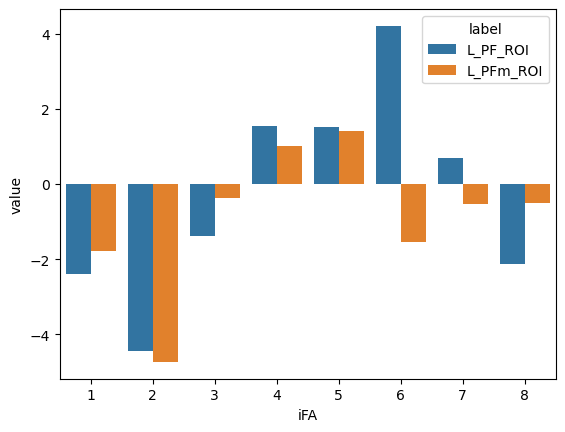

In [162]:
pattern = '|'.join(map(str, [x+'_' for x in ['L_PFm','L_PF']]))
df_plot = df_results_wide.loc[df_results_wide['label'].str.contains(pattern, na=False)].copy()

df_plot = df_plot.melt(id_vars=['label'],value_vars=[1, 2, 3, 4, 5, 6,7, 8])
sns.barplot(df_plot,x='iFA',y='value',hue='label')

iFA,ROI_idx,label,RegionLongName,Region,LR,1,2,3,4,5,6,7,8
113,114.0,L_PF_ROI,Area_PF_Complex,PF,L,-2.396603,-4.453824,-1.371037,1.545529,1.522101,4.212828,0.699323,-2.141636
114,115.0,L_PFm_ROI,Area_PFm_Complex,PFm,L,-1.785758,-4.738694,-0.374851,1.014995,1.412798,-1.549983,-0.538002,-0.509697


In [111]:
df_results_wide.loc[(
    (df_results_wide[1] < 0)
    # & (df_results_wide[2] > 0)
    & (df_results_wide[4] < 0)
    & (df_results_wide[5] > 0)
    & (df_results_wide[6] < 0)
    & (df_results_wide[7] > 0)
    & (df_results_wide[8] < 0)
)]

iFA,ROI_idx,label,RegionLongName,Region,LR,1,2,3,4,5,6,7,8
14,15.0,L_VMV2_ROI,VentroMedial_Visual_Area_2,VMV2,L,-0.923639,-1.288064,0.017516,-0.875871,2.13280,-1.838466,0.138662,-0.021199
317,318.0,R_8BM_ROI,Area_8BM,8BM,R,-2.144178,-3.370833,-1.245149,-0.053764,2.73924,-0.935076,1.140385,-0.517228


In [ ]:
pattern = '|'.join(map(str, ['_'+x+'_' for x in List_network]))
    
df_output.loc[~df_output['label'].str.contains(pattern, na=False),'alpha'] = 0

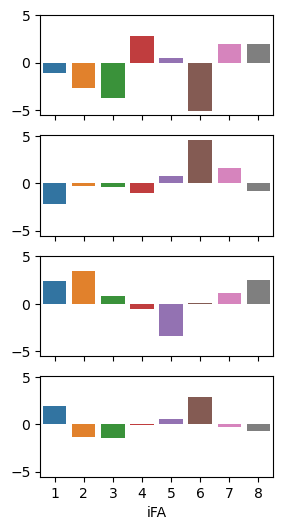

In [87]:
import seaborn as sns
import matplotlib.pyplot as plt
List_network1 = ['45','A5','STSdp','STSvp','A4','PSL','STSda','STGa']
List_network2 = ['IFSa','IFSp','IFJa','IFJp','PHT','TE1p','TE2p','TF','PH','FFC','PreS','H','PHA1','PHA2','PHA3']
List_network3 = ['RSC','d23ab','v23ab','31pv','31pd','7m','POS2','POS1']
List_network4 = ['MI','FOP4','FOP5','4','3a','3b','24dd','24dv','p24pr']

fig,axes = plt.subplots(nrows=4,ncols=1,figsize=(3,6),sharex=True,sharey=True)
df_results_wide = df_results.pivot(index=['ROI_idx','label','RegionLongName','Region','LR'], columns='iFA', values='ROI_value').reset_index()
dfs_plot = []
for i,List_network in enumerate([List_network1,List_network2,List_network3,List_network4]):
    pattern = '|'.join(map(str, ['_'+x+'_' for x in List_network]))
    df_plot = df_results_wide.loc[df_results_wide['label'].str.contains(pattern, na=False)].mean(numeric_only=True)[1:8+1].to_frame().T
    df_plot['network'] = f"{i+1}"
    dfs_plot.append(df_plot)

    sns.barplot(df_plot,ax=axes[i])
dfs_plot = pd.concat(dfs_plot)

<Axes: xlabel='iFA'>

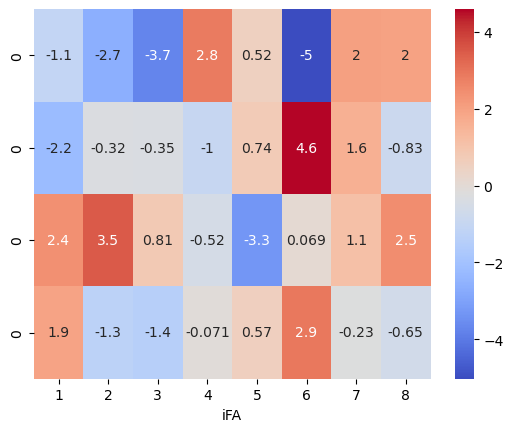

In [93]:
sns.heatmap(dfs_plot.loc[:,1:8],cmap='coolwarm',annot=True)

iFA,1,2,3,4,5,6,7,8
0,-1.095951,-2.654537,-3.726159,2.831526,0.515922,-5.024958,2.004477,1.986372
0,-2.210614,-0.323446,-0.353941,-1.001263,0.735431,4.594109,1.623061,-0.828483
0,2.391997,3.475418,0.807689,-0.524888,-3.330785,0.068977,1.125648,2.483828
0,1.929644,-1.274485,-1.428099,-0.071380,0.568491,2.934816,-0.231917,-0.649219
